In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
import numpy as np
import re
import seaborn as sns
from pathlib import Path
import pandasai as pai
from pandasai_litellm.litellm import LiteLLM
from litellm import completion

In [4]:
files = {
    'clinic': 'cc_clinic_level.csv',
    'doctor': 'cc_doctor.csv',
    'hourly': 'cc_hourly.csv',
    'patient': 'cc_patient.csv'
}

summary_data = []

for key, fileName in files.items():
    df = pd.read_csv(fileName)
    
    initial_rows = len(df)
    missing_values_count = df.isna().sum().sum()
    
    # Cleaning
    df_no_dups = df.drop_duplicates()
    duplicates_removed = initial_rows - len(df_no_dups)
    
    numeric_cols = df_no_dups.select_dtypes(include=[np.number]).columns
    categorical_cols = df_no_dups.select_dtypes(exclude=[np.number]).columns
    
    df_cleaned = df_no_dups.copy()
    df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(0)
    df_cleaned[categorical_cols] = df_cleaned[categorical_cols].fillna("Unknown")
    
    out_name = f'cleaned_{fileName}'
    df_cleaned.to_csv(out_name, index=False)
    
    summary_data.append({
        'File': fileName,
        'Initial Rows': initial_rows,
        'Duplicates Removed': duplicates_removed,
        'Missing Values Filled': missing_values_count,
        'Saved As': out_name
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string())

                  File  Initial Rows  Duplicates Removed  Missing Values Filled                     Saved As
0  cc_clinic_level.csv            46                   0                      0  cleaned_cc_clinic_level.csv
1        cc_doctor.csv           231                   0                      0        cleaned_cc_doctor.csv
2        cc_hourly.csv        157419                   0                 376316        cleaned_cc_hourly.csv
3       cc_patient.csv        241159               33895                 493506       cleaned_cc_patient.csv


In [6]:
from pathlib import Path
import pandas as pd

data_dir = Path("dataset")

df_clinic_level = pd.read_csv(data_dir / "cc_clinic_level.csv")
df_doctor = pd.read_csv(data_dir / "cc_doctor.csv")
df_hourly = pd.read_csv(data_dir / "cc_hourly.csv")
df_patient = pd.read_csv(data_dir / "cc_patient.csv")

df_clinic_level = pai.DataFrame(df_clinic_level)
df_doctor = pai.DataFrame(df_doctor)
df_hourly = pai.DataFrame(df_hourly)
df_patient = pai.DataFrame(df_patient)

In [7]:
def generate_Response(question: str, dataframes: list, model_id: str = None, api_key: str = None):
    """
    Generate a response using PandasAI for the given question.
    
    Args:
        question: The question to ask
        dataframes: List of PandasAI DataFrames to query
        model_id: The LLM model identifier
        api_key: API key for the LLM
    
    Returns:
        tuple: (response, elapsed_time)
    """
    default_api_key = "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"
    default_model = "nvidia_nim/meta/llama-3.1-405b-instruct"
    
    # Configure the LLM
    llm = LiteLLM(
        model=model_id or default_model,
        api_key=api_key or default_api_key,
        stream=False,
    )
    pai.config.set({"llm": llm, "save_charts": False,"verbose": False})
    
    start_time = time.time()
    response = pai.chat(question, *dataframes)
    elapsed_time = time.time() - start_time
    
    return response, elapsed_time

In [8]:
def extract_Generated_code(log_path: str = "pandasai.log"):
    """
    Extract the full generated code from PandasAI log.
    
    Returns:
        dict: {"sql_query": str, "full_code": str}
    """
    from pathlib import Path
    
    log_file = Path(log_path)
    if not log_file.exists():
        return {"sql_query": "", "full_code": ""}
    
    text = log_file.read_text(encoding="utf-8")
    
    # --- Extract full generated code from "Executing code:" section ---
    full_code = ""
    # Pattern to find code after "Executing code:" until next log entry or end
    exec_pattern = r'\[INFO\] Executing code:\s*(.+?)(?=\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2} \[INFO\]|$)'
    exec_matches = re.findall(exec_pattern, text, re.DOTALL)
    if exec_matches:
        full_code = exec_matches[-1].strip()
    
    # --- Extract SQL query from the full code ---
    sql_query = ""
    # Pattern for triple-quoted multi-line SQL
    multi_line_pattern = r'sql_query\s*=\s*"""(.+?)"""'
    single_quote_pattern = r"sql_query\s*=\s*'([^']+)'"
    double_quote_pattern = r'sql_query\s*=\s*"([^"]+)"'

    # Search in full_code first, then in entire text
    search_text = full_code if full_code else text
    
    matches = re.findall(multi_line_pattern, search_text, re.DOTALL)
    if not matches:
        matches = re.findall(single_quote_pattern, search_text)
    if not matches:
        matches = re.findall(double_quote_pattern, search_text)
    if matches:
        sql_query = matches[-1].strip()
    
    return {"sql_query": sql_query, "full_code": full_code}


def clear_log(log_path: str = "pandasai.log"):
    """Clear the PandasAI log file after extraction."""
    from pathlib import Path
    log_file = Path(log_path)
    if log_file.exists():
        log_file.write_text("", encoding="utf-8")

In [9]:
def validation_Response(query: str, question: str,response=None,answer=None) -> bool:
    if not query:
        return False
    
    try:
        validation = completion(
            model="nvidia_nim/meta/llama-3.1-405b-instruct",
            messages=[{
                "role": "user", 
                "content": f"""You are a query validator.
                Question: {question}
                Code: {query}
                response: {response} if response is chart or visualization, compare answer with the query else compare response with the answer
                answer: {answer}
                Does this code correctly retrieve the data required to answer the question?
                Respond with ONLY one word: TRUE or FALSE."""
            }],
            api_key= "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"
            
        )
        return validation.choices[0].message.content.strip()
        
    except Exception as e:
        print(f"⚠️ Validation error: {e}")
        return None

In [10]:
def error_explaination_Response(query: str, question: str, response=None, answer=None) -> str:
    if not query:
        return "No code generated to validate."
    
    try:
        explanation = completion(
            model="nvidia_nim/meta/llama-3.1-405b-instruct",
            messages=[{
                "role": "user", 
                "content": f"""You are a helpful assistant that explains errors in code.
                Question: {question}
                Code: {query}
                Response: {response}
                Answer: {answer}
                the code is determine by the llms judge passed to you thats means it is wrong, explain what is wrong with it and how to fix it. If the code is correct, say "The code is correct."."""
            }],
            api_key= "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"
        )
        return explanation.choices[0].message.content.strip()
        
    except Exception as e:
        print(f"⚠️ Explanation error: {e}")
        return "An error occurred while generating the explanation."

Response: exports\charts\temp_chart_4cbf57a3-853f-49ac-a721-3386439a6b5d.png

SQL Query:
SELECT StaffName, TotalRevenue
    FROM table_c83679f393c19ab82f71054c6c3facb6
    ORDER BY TotalRevenue DESC
    LIMIT 5;

Full Code:
import pandas as pd
import matplotlib.pyplot as plt
sql_query = """
    SELECT StaffName, TotalRevenue
    FROM table_c83679f393c19ab82f71054c6c3facb6
    ORDER BY TotalRevenue DESC
    LIMIT 5;
"""
df = execute_sql_query(sql_query)
plt.figure(figsize=(10, 6))
plt.bar(df['StaffName'], df['TotalRevenue'], color='skyblue')
plt.xlabel('Staff Name')
plt.ylabel('Total Revenue')
plt.title('Top 5 High Revenue Doctors')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('exports\\charts\\temp_chart_4cbf57a3-853f-49ac-a721-3386439a6b5d.png')
result = {'type': 'plot', 'value': 'exports\\charts\\temp_chart_4cbf57a3-853f-49ac-a721-3386439a6b5d.png'}

Is Correct: FALSE.

Error Explanation:
The code provided appears to be generally correct for plotting the top 5 high revenue 

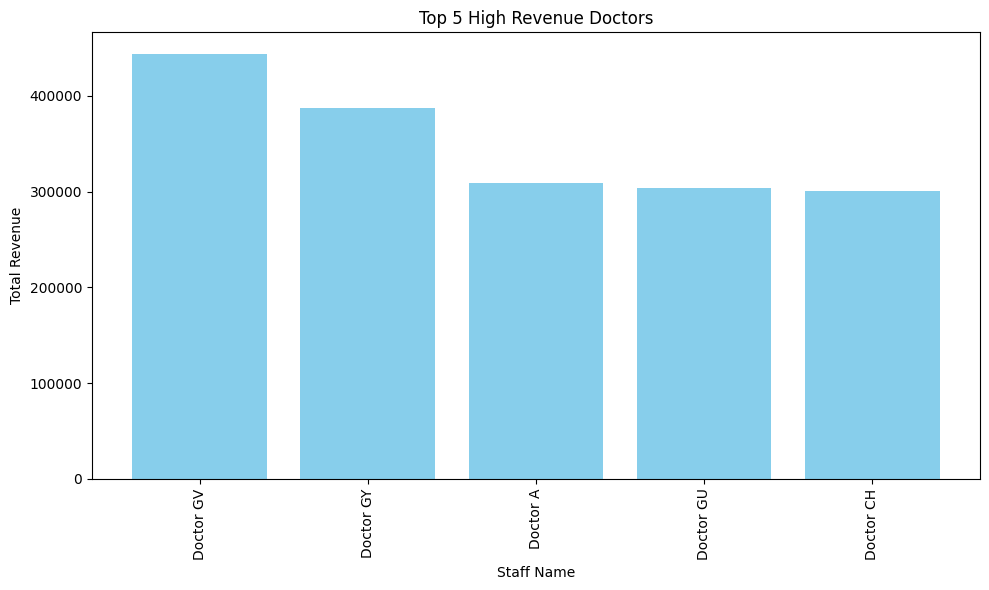

In [11]:
clear_log()
# Simple test using the helper functions
question = "Plot the  the top 5 high revenue doctors working in clinics I"

# Use generate_Response function
response, elapsed_time = generate_Response(question, [df_doctor, df_hourly, df_patient,df_clinic_level])
print(f"Response: {response.value if hasattr(response, 'value') else response}")

# Extract full generated code
generated = extract_Generated_code()
print(f"\nSQL Query:\n{generated['sql_query']}")
print(f"\nFull Code:\n{generated['full_code']}")

# Use validation_Response function with full_code for complete validation
code_to_validate = generated['full_code'] if generated['full_code'] else generated['sql_query']
is_correct = validation_Response(code_to_validate, question, response=response, answer=""""DOCTOR HE treats 1,996 patients at CLINIC T.""")
print(f"\nIs Correct: {is_correct}")

# Check if validation returned "FALSE" (string comparison, case-insensitive)
if is_correct and "false" in str(is_correct).lower():
    explanation = error_explaination_Response(code_to_validate, question, response)
    print(f"\nError Explanation:\n{explanation}")

print(f"Time taken: {elapsed_time:.2f} seconds")

In [ ]:
# Benchmark Test Questions with Expected Answers
# Each entry: {"question": str, "answer": str, "dataframes": list}

benchmark_questions = {
    "easy": [
        {
            "question": "Which clinic has the highest TotalRevenue?",
            "answer": "Clinic I",
            "dataframes": [df_clinic_level]
        },
        {
            "question": "What is the average TotalRevenue across all clinics?",
            "answer": "1,220,906.65",
            "dataframes": [df_clinic_level]
        },
        {
            "question": "List all unique Districts present in the dataset.",
            "answer": "Bandar Enstek, Bangi, Batang Kali, Batu Caves, Bayan Lepas, Central KL, Cheras, Desa Pandan, Dungun, Georgetown, Hulu Langat, Ipoh, Kajang, Kota Bharu, Kuala Langat, Kuala Lumpur, Kuantan, Kulim, Mantin, Muar, Pasir Mas, Petaling, Petaling Jaya, Presint 8, Rawang, Semenyih, Sepang, Seremban, Setia Alam, Shah Alam, Skudai, Wakaf Bharu",
            "dataframes": [df_clinic_level]
        },
        {
            "question": "Which hour has the highest patient count?",
            "answer": "2025-10-13 20:00:00",
            "dataframes": [df_hourly]
        },
        {
            "question": "Which state generates the highest total revenue?",
            "answer": "Selangor",
            "dataframes": [df_clinic_level]
        }
    ],
    "medium": [
        {
            "question": "Which doctor treats the highest number of patients from Malay ethnicity?",
            "answer": "Doctor B",
            "dataframes": [df_doctor, df_patient]
        },
        {
            "question": "Which doctor sees the most patients from Married social status group?",
            "answer": "Doctor BZ",
            "dataframes": [df_doctor, df_patient]
        },
        {
            "question": "Which doctor has the highest number of patients from different country/geography?",
            "answer": "Doctor AW treats the most patients from Australia, Bangladesh, Canada, Germany, India, Japan, Malaysia, Philippines, and Singapore",
            "dataframes": [df_doctor, df_patient]
        },
        {
            "question": "Which clinic has the highest revenue and how many doctors work there?",
            "answer": "Clinic I with 15 doctors",
            "dataframes": [df_clinic_level, df_doctor]
        },
        {
            "question": "Which doctor treats the highest number of patients from Malay ethnicity in the highest revenue clinic?",
            "answer": "Doctor BY in Clinic I",
            "dataframes": [df_clinic_level, df_doctor, df_patient]
        }
    ],
    "hard": [
        {
            "question": "Plot Top 3 clinics by total revenue",
            "answer": "Bar chart ",
            "dataframes": [df_clinic_level]
        },
        {
            "question": "Plot the relationship between a clinic's total revenue and the number of doctors it employs.",
            "answer": "Scatter plot of revenue vs doctor count",
            "dataframes": [df_clinic_level, df_doctor]
        },
        {
            "question": "Plot Top 3 hourly revenue trends.",
            "answer": "Line chart of hourly revenue trends",
            "dataframes": [df_hourly]
        },
        {
            "question": "Create a stacked bar chart of show top 5 patient religion counts by state. Visualize Top 3 religious demographics in regions.",
            "answer": "Stacked bar chart of religions by state",
            "dataframes": [df_clinic_level, df_patient]
        },
        {
            "question": "Plot the  the top 5 high revenue doctors working in clinics I",
            "answer": "Combined chart of top clinics and doctors",
            "dataframes": [df_clinic_level, df_doctor]
        }
    ]
}

# Models to test
models_to_test = [
    ("nvidia_nim/meta/llama-3.1-8b-instruct", "Llama-3.1-8B"),
    ("nvidia_nim/google/gemma-2-27b-it", "Gemma-2-27B"),
    ("nvidia_nim/meta/llama3-70b-instruct", "Llama3-70B"),
    ("nvidia_nim/meta/llama-3.1-405b-instruct", "Llama-3.1-405B"),
    ("nvidia_nim/mistralai/mistral-large-3-675b-instruct-2512", "Mistral-Large-3-675B")
]

print(f"📋 Benchmark configured:")
print(f"   Easy questions: {len(benchmark_questions['easy'])}")
print(f"   Medium questions: {len(benchmark_questions['medium'])}")
print(f"   Hard questions: {len(benchmark_questions['hard'])}")
print(f"   Models to test: {len(models_to_test)}")

📋 Benchmark configured:
   Easy questions: 5
   Medium questions: 5
   Hard questions: 5
   Models to test: 5


In [ ]:
# Benchmark Runner - EASY & MEDIUM ONLY
NUM_RUNS = 3
MAX_RETRIES = 1
RESULTS_FILE = "exports/benchmark_results_easy_medium.csv"

os.makedirs("exports", exist_ok=True)

# Load existing results if available
if os.path.exists(RESULTS_FILE) and os.path.getsize(RESULTS_FILE) > 0:
    try:
        results_df = pd.read_csv(RESULTS_FILE)
        results = results_df.to_dict('records')
        print(f"📂 Loaded {len(results)} existing results")
    except pd.errors.EmptyDataError:
        results = []
else:
    results = []
    print("📂 Starting fresh benchmark")


def get_completed_tests(results):
    return {(r['model'], r['difficulty'], r['question'], r.get('run_num', 1)) for r in results}


def save_results(results, filepath):
    pd.DataFrame(results).to_csv(filepath, index=False)


def run_single_test(model_id, model_name, question_data, difficulty, run_num):
    question = question_data["question"]
    expected_answer = question_data["answer"]
    dataframes = question_data["dataframes"]
    
    for attempt in range(MAX_RETRIES + 1):
        try:
            clear_log()
            response, elapsed_time = generate_Response(question, dataframes, model_id=model_id)
            response_value = response.value if hasattr(response, 'value') else str(response)
            
            generated = extract_Generated_code()
            sql_query = generated["sql_query"]
            full_code = generated["full_code"]
            
            code_to_validate = full_code if full_code else sql_query
            is_correct = None
            if code_to_validate:
                is_correct = validation_Response(code_to_validate, question, response=response_value, answer=expected_answer)
            
            return {
                "model": model_name, "difficulty": difficulty, "question": question,
                "expected_answer": expected_answer, "run_num": run_num,
                "response": response_value, "sql_query": sql_query, "full_code": full_code,
                "is_correct": is_correct, "time_seconds": round(elapsed_time, 2),
                "success": True, "error": None
            }
        except Exception as e:
            if attempt < MAX_RETRIES:
                print(f"      ⚠️ Retry {attempt + 1}...")
                time.sleep(2)
            else:
                return {
                    "model": model_name, "difficulty": difficulty, "question": question,
                    "expected_answer": expected_answer, "run_num": run_num,
                    "response": None, "sql_query": None, "full_code": None,
                    "is_correct": False, "time_seconds": None, "success": False, "error": str(e)[:200]
                }


# Only test EASY and MEDIUM
difficulties_to_test = ["easy", "medium"]
total_questions = sum(len(benchmark_questions[d]) for d in difficulties_to_test)
total_tests = len(models_to_test) * total_questions * NUM_RUNS
completed_tests = get_completed_tests(results)

print("\n" + "=" * 70)
print(f"🚀 EASY + MEDIUM BENCHMARK")
print(f"   {len(models_to_test)} models × {total_questions} questions × {NUM_RUNS} runs = {total_tests} tests")
print(f"   Already completed: {len(completed_tests)}")
print("=" * 70)

try:
    for run_num in range(1, NUM_RUNS + 1):
        print(f"\n{'='*70}\n🔄 RUN {run_num}/{NUM_RUNS}\n{'='*70}")
        
        for model_id, model_name in models_to_test:
            print(f"\n🤖 {model_name}")
            
            for difficulty in difficulties_to_test:
                questions = benchmark_questions[difficulty]
                print(f"  📊 {difficulty.upper()}")
                
                for idx, q_data in enumerate(questions):
                    if (model_name, difficulty, q_data["question"], run_num) in completed_tests:
                        print(f"    ⏭️ Q{idx+1}: Skipped")
                        continue
                    
                    print(f"    🔍 Q{idx+1}: {q_data['question'][:40]}...")
                    result = run_single_test(model_id, model_name, q_data, difficulty, run_num)
                    results.append(result)
                    
                    status = "✅" if str(result["is_correct"]).upper() == "TRUE" else "❌" if result["success"] else "💥"
                    print(f"       {status} {result['time_seconds']}s | {result['is_correct']}")
                    save_results(results, RESULTS_FILE)

except KeyboardInterrupt:
    print("\n⚠️ Interrupted!")
    save_results(results, RESULTS_FILE)

print(f"\n✅ Easy/Medium complete! Results: {len(results)}")
print(f"📁 Saved to: {RESULTS_FILE}")

📂 Starting fresh benchmark

🚀 EASY + MEDIUM BENCHMARK
   5 models × 10 questions × 3 runs = 150 tests
   Already completed: 0

🔄 RUN 1/3

🤖 Llama-3.1-8B
  📊 EASY
    🔍 Q1: Which clinic has the highest TotalRevenu...
{'type': 'string', 'value': 'The clinic with the highest TotalRevenue is Clinic I.'}
       ✅ 5.89s | TRUE
    🔍 Q2: What is the average TotalRevenue across ...
{'type': 'number', 'value': 1220906.6519565217}
       ✅ 2.24s | TRUE
    🔍 Q3: List all unique Districts present in the...
{'type': 'dataframe', 'value': ['Shah Alam', 'Petaling Jaya', 'Kuala Langat', 'Batu Caves', 'Batang Kali', 'Cheras', 'Central KL', 'Presint 8', 'Bandar Enstek', 'Pasir Mas', 'Seremban', 'Bayan Lepas', 'Kajang', 'Kota Bharu', 'Kuantan', 'Sepang', 'Wakaf Bharu', 'Bangi', 'Rawang', 'Desa Pandan', 'Muar', 'Ipoh', 'Kuala Lumpur', 'Petaling', 'Hulu Langat', 'Skudai', 'Mantin', 'Georgetown', 'Setia Alam', 'Kulim', 'Dungun', 'Semenyih']}
{'type': 'dataframe', 'value': ['Kota Bharu', 'Shah Alam', 'Chera

📂 Loaded 50 existing hard results

   5 models × 5 questions × 3 runs = 75 tests
   Already completed: 50

🔄 RUN 1/3

🤖 Llama-3.1-8B
  ⏭️ Q1: Skipped
  ⏭️ Q2: Skipped
  ⏭️ Q3: Skipped
  ⏭️ Q4: Skipped
  ⏭️ Q5: Skipped

🤖 Gemma-2-27B
  ⏭️ Q1: Skipped
  ⏭️ Q2: Skipped
  ⏭️ Q3: Skipped
  ⏭️ Q4: Skipped
  ⏭️ Q5: Skipped

🤖 Llama3-70B
  ⏭️ Q1: Skipped
  ⏭️ Q2: Skipped
  ⏭️ Q3: Skipped
  ⏭️ Q4: Skipped
  ⏭️ Q5: Skipped

🤖 Llama-3.1-405B
  ⏭️ Q1: Skipped
  ⏭️ Q2: Skipped
  ⏭️ Q3: Skipped
  ⏭️ Q4: Skipped
  ⏭️ Q5: Skipped

🤖 Mistral-Large-3-675B
  ⏭️ Q1: Skipped
  ⏭️ Q2: Skipped
  ⏭️ Q3: Skipped
  ⏭️ Q4: Skipped
  ⏭️ Q5: Skipped

🔄 RUN 2/3

🤖 Llama-3.1-8B
  ⏭️ Q1: Skipped
  ⏭️ Q2: Skipped
  ⏭️ Q3: Skipped
  ⏭️ Q4: Skipped
  ⏭️ Q5: Skipped

🤖 Gemma-2-27B
  ⏭️ Q1: Skipped
  ⏭️ Q2: Skipped
  ⏭️ Q3: Skipped
  ⏭️ Q4: Skipped
  ⏭️ Q5: Skipped

🤖 Llama3-70B
  ⏭️ Q1: Skipped
  ⏭️ Q2: Skipped
  ⏭️ Q3: Skipped
  ⏭️ Q4: Skipped
  ⏭️ Q5: Skipped

🤖 Llama-3.1-405B
  ⏭️ Q1: Skipped
  ⏭️ Q2: Skipped
  ⏭️ Q3:

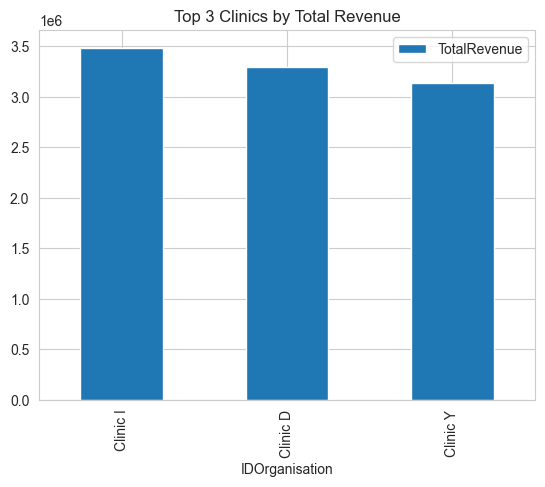

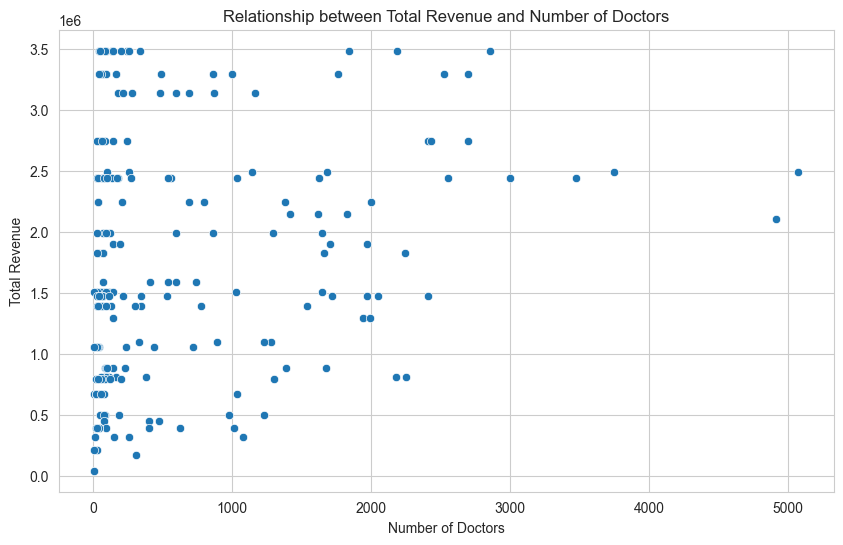

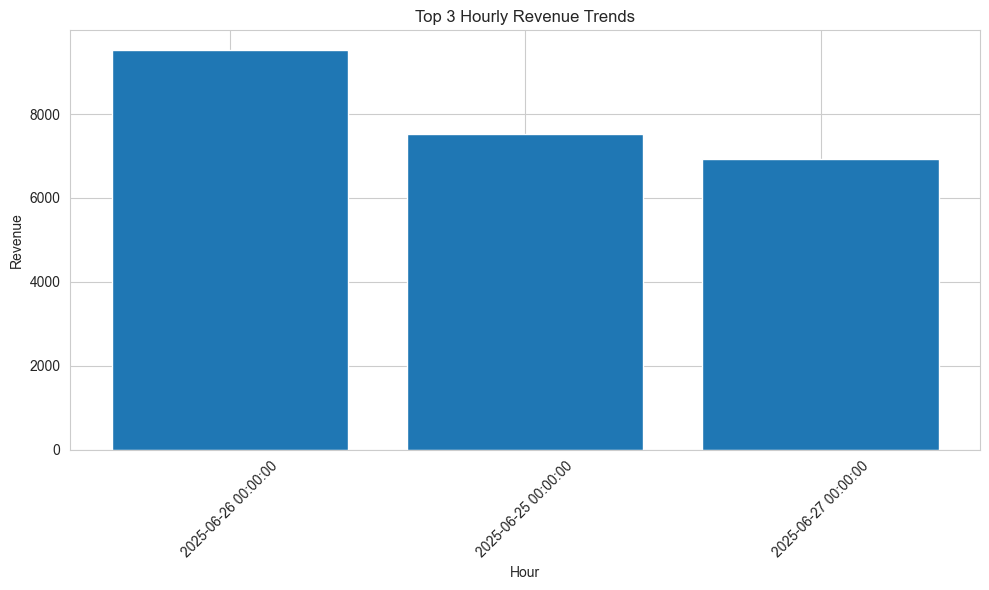

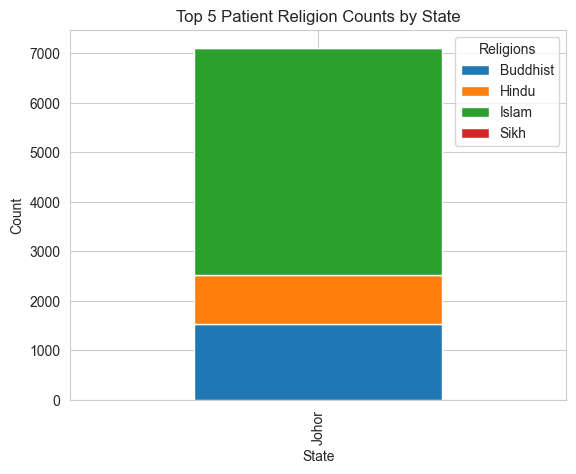

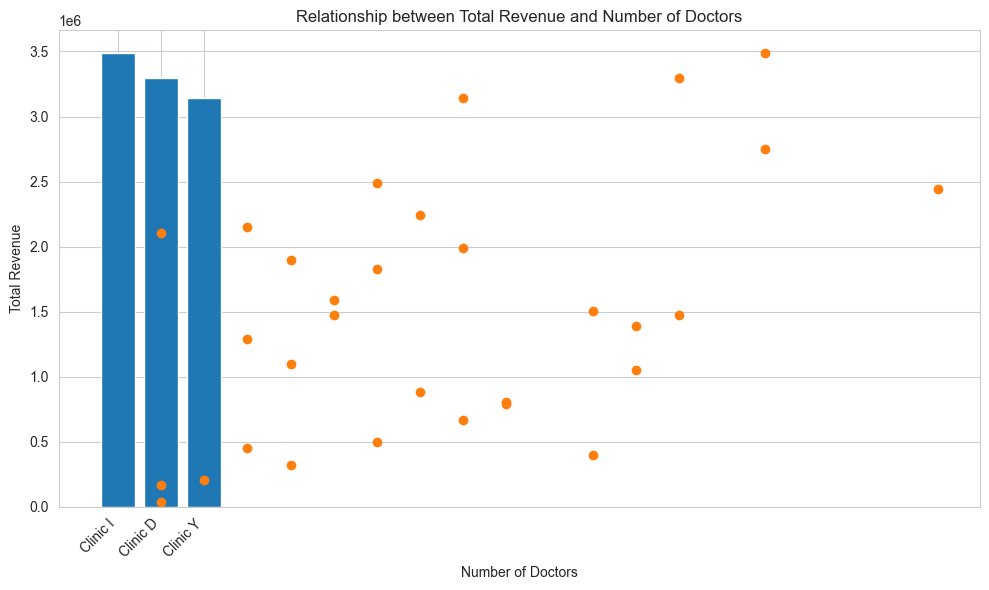

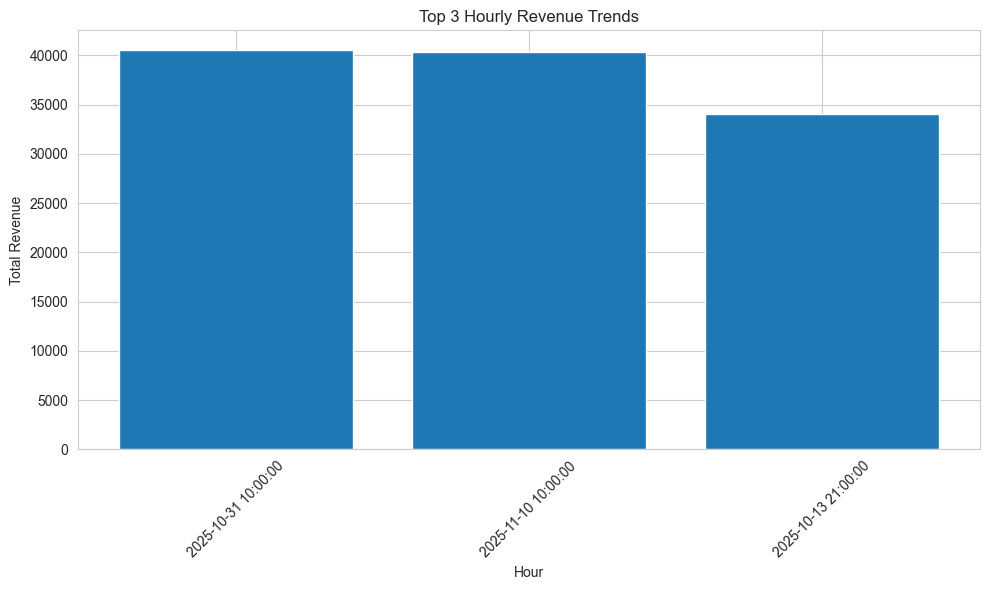

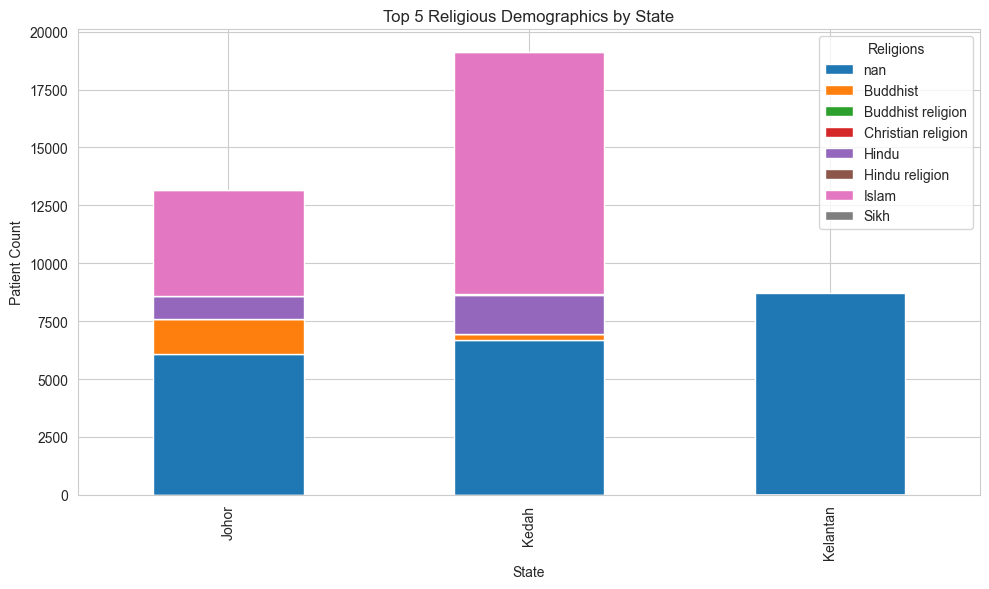

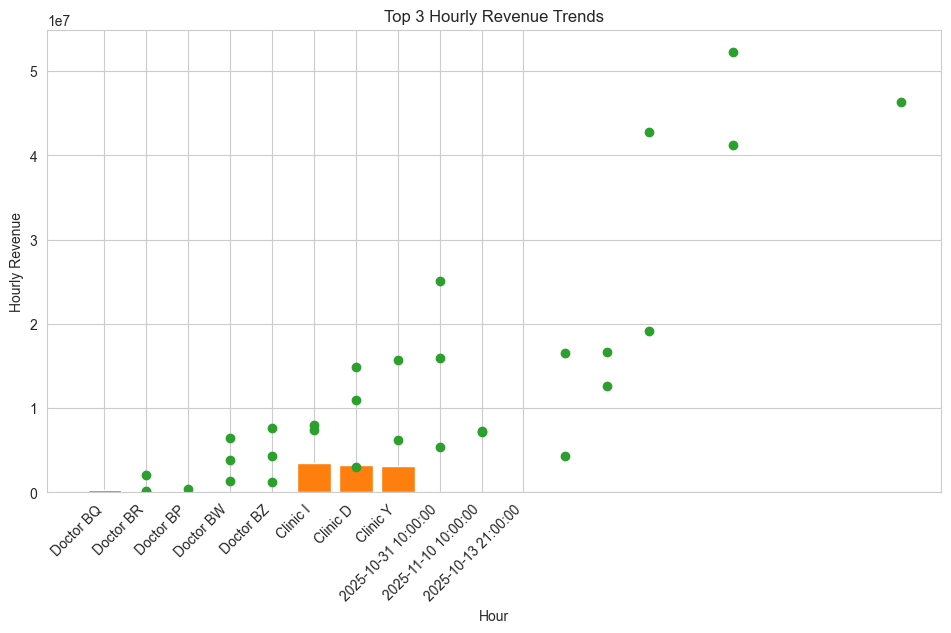

<Figure size 1000x600 with 0 Axes>

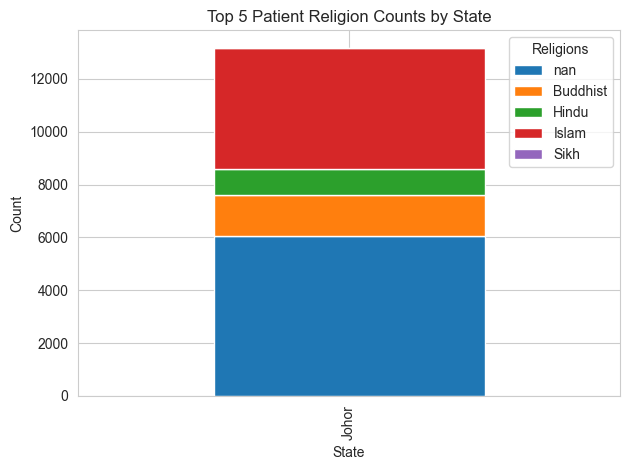

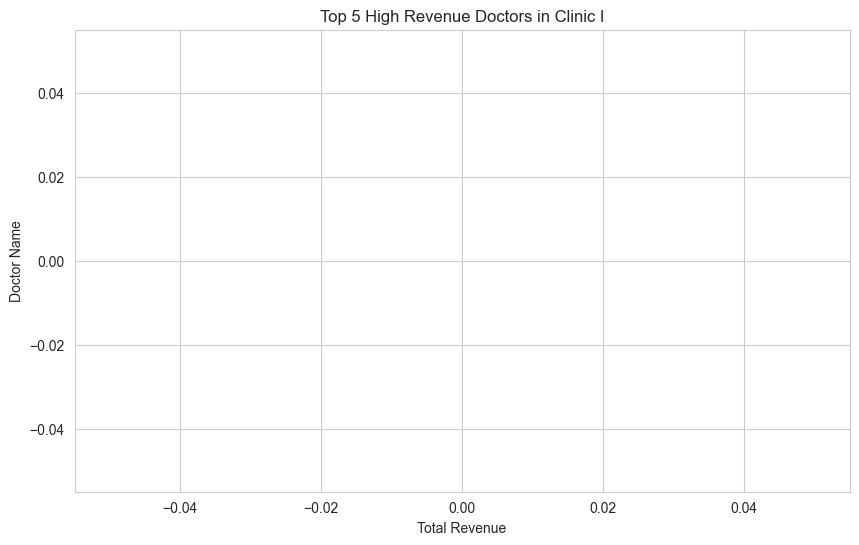

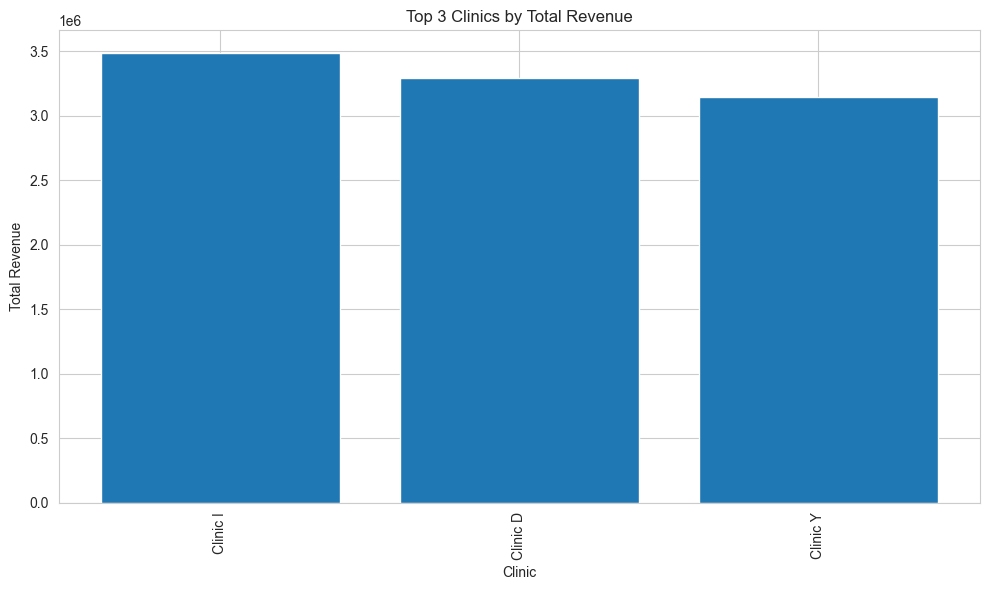

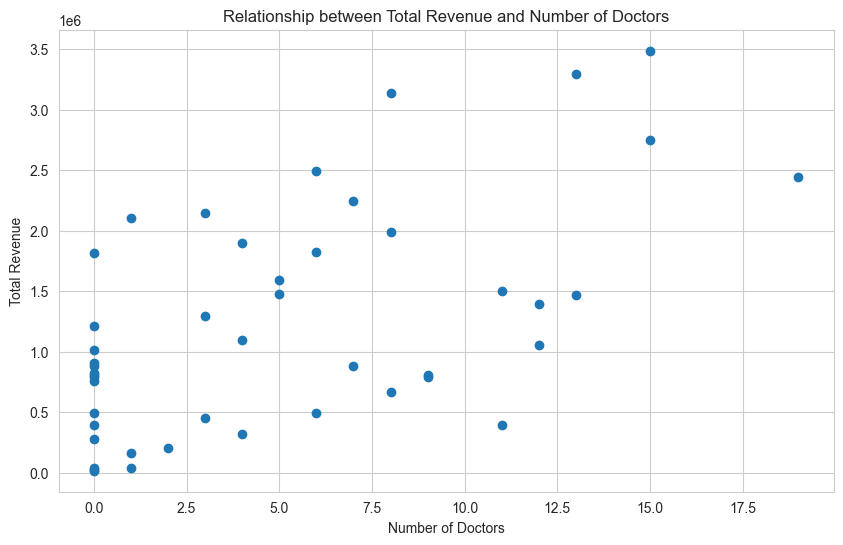

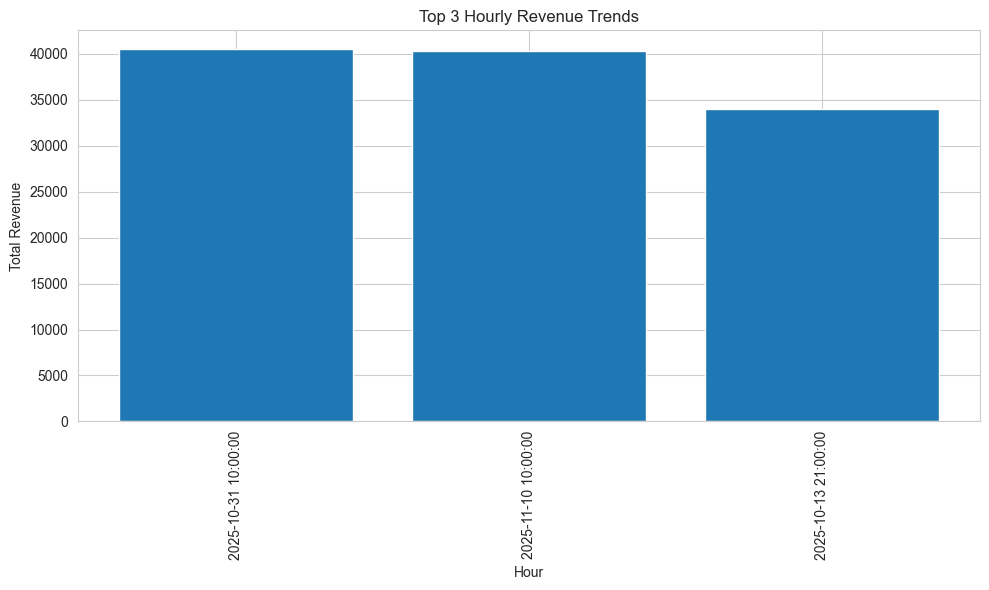

<Figure size 1000x600 with 0 Axes>

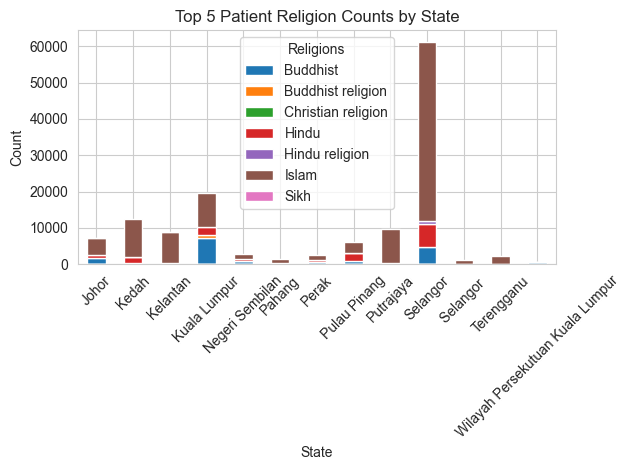

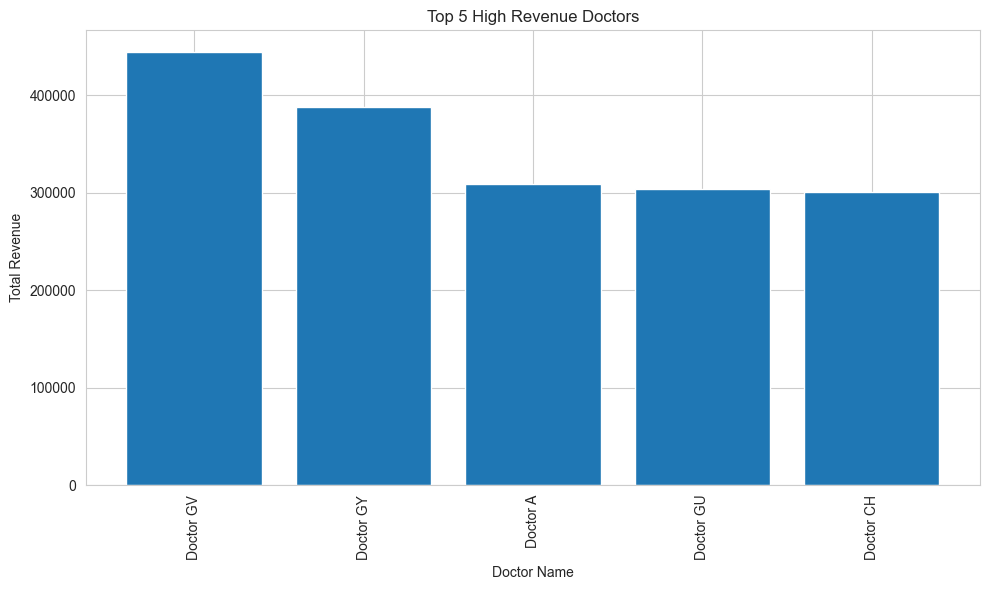

<Figure size 1200x800 with 0 Axes>

In [44]:
NUM_RUNS = 3
MAX_RETRIES = 1
RESULTS_FILE_HARD = "exports/benchmark_results_hard.csv"

# Load existing hard results
if os.path.exists(RESULTS_FILE_HARD) and os.path.getsize(RESULTS_FILE_HARD) > 0:
    try:
        hard_results_df = pd.read_csv(RESULTS_FILE_HARD)
        hard_results = hard_results_df.to_dict('records')
        print(f"📂 Loaded {len(hard_results)} existing hard results")
    except pd.errors.EmptyDataError:
        hard_results = []
else:
    hard_results = []
    print("📂 Starting fresh hard benchmark")

completed_hard = get_completed_tests(hard_results)
hard_questions = benchmark_questions["hard"]
total_hard = len(models_to_test) * len(hard_questions) * NUM_RUNS

print("\n" + "=" * 70)
print(f"   {len(models_to_test)} models × {len(hard_questions)} questions × {NUM_RUNS} runs = {total_hard} tests")
print(f"   Already completed: {len(completed_hard)}")
print("=" * 70)

try:
    for run_num in range(1, NUM_RUNS + 1):
        print(f"\n{'='*70}\n🔄 RUN {run_num}/{NUM_RUNS}\n{'='*70}")
        
        for model_id, model_name in models_to_test:
            print(f"\n🤖 {model_name}")
            
            for idx, q_data in enumerate(hard_questions):
                question = q_data["question"]
                
                if (model_name, "hard", question, run_num) in completed_hard:
                    print(f"  ⏭️ Q{idx+1}: Skipped")
                    continue
                
                print(f"\n  🎨 Q{idx+1}: {question[:50]}...")
                print(f"     Expected: {q_data['answer']}")
                
                try:
                    clear_log()
                    response, elapsed_time = generate_Response(question, q_data["dataframes"], model_id=model_id)
                    response_value = response.value if hasattr(response, 'value') else str(response)
                    
                    
                    generated = extract_Generated_code()
                    sql_query = generated["sql_query"]
                    full_code = generated["full_code"]
                    
                    code_to_validate = full_code if full_code else sql_query
                    is_correct = None
                    if code_to_validate:
                        is_correct = validation_Response(code_to_validate, question, response=response_value)
                    
                    # Display the chart if generated
                    print(f"     Response: {str(response_value)[:100]}...")
                    print(f"     Time: {elapsed_time:.2f}s")
                    print()
                    status = "✅" if str(result["is_correct"]).upper() == "TRUE" else "❌" if result["success"] else "💥"
                    print(f"     Status: {status}")
                    print(f" Question: {question}, Model: {model_name}, Correct: {is_correct}")
                    # For plots, we skip auto-validation - mark as needs_review
                    result = {
                        "model": model_name, "difficulty": "hard", "question": question,
                        "expected_answer": q_data["answer"], "run_num": run_num,
                        "response": response_value, "sql_query": generated["sql_query"],
                        "full_code": generated["full_code"], "is_correct": is_correct,
                        "time_seconds": round(elapsed_time, 2), "success": True, "error": None
                    }
                    
                except Exception as e:
                    print(f"     💥 Error: {str(e)[:100]}")
                    result = {
                        "model": model_name, "difficulty": "hard", "question": question,
                        "expected_answer": q_data["answer"], "run_num": run_num,
                        "response": None, "sql_query": None, "full_code": None,
                        "is_correct": False, "time_seconds": None, "success": False, "error": str(e)[:200]
                    }
                
                hard_results.append(result)
                save_results(hard_results, RESULTS_FILE_HARD)
                print(f"     💾 Saved")

except KeyboardInterrupt:
    print("\n⚠️ Interrupted!")
    save_results(hard_results, RESULTS_FILE_HARD)

print(f"\n✅ Hard benchmark complete! Results: {len(hard_results)}")
print(f"📁 Saved to: {RESULTS_FILE_HARD}")


In [29]:
df_em = pd.read_csv('exports/verified_benchmark_easy_medium_MODIFY.csv')
df_hard = pd.read_csv('exports/verified_benchmark_hard.csv')
df = pd.concat([df_hard, df_em], ignore_index=True)

total_rows = len(df_hard)
total_correct = df_hard["judge_was_right"].sum()
total_incorrect = total_rows - total_correct

plt.figure(figsize=(6, 6))
plt.pie([total_correct, total_incorrect], labels=['Correct', 'Incorrect'], autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
plt.title('Overall LLM Judge Accuracy')
plt.tight_layout()
plt.savefig('total_overall_accuracy.png')
plt.close()

print(f"Accuracy: {total_correct/total_rows*100:.2f}%")

Accuracy: 62.34%


In [3]:
file1 = 'exports/verified_benchmark_easy_medium_MODIFY.csv'
file2 = 'exports/verified_benchmark_hard_Modify.csv'

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

df = pd.concat([df1, df2], ignore_index=True)

valid_models = ['Gemma-2-27B', 'Llama-3.1-405B', 'Llama-3.1-8B', 'Llama3-70B', 'Mistral-Large-3-675B']
df = df[df['model'].isin(valid_models)]

col_acc = 'is_correct_bool' if 'is_correct_bool' in df.columns else 'is_correct'

stats = df.groupby('model').agg(
    accuracy=(col_acc, 'mean'),
    latency=('time_seconds', 'mean')
).reset_index()

stats['accuracy'] = stats['accuracy'] * 100

plt.figure(figsize=(12, 8))

for i, row in stats.iterrows():
    plt.scatter(row['latency'], row['accuracy'], s=500, label=row['model'], alpha=0.7, edgecolors='w', linewidth=2)
    plt.text(row['latency'], row['accuracy'] + 1.5, row['model'], ha='center', va='bottom', fontsize=12, weight='bold')

plt.xlabel('Average Latency (seconds)', fontsize=14, weight='bold')
plt.ylabel('Average Accuracy (%)', fontsize=14, weight='bold')
plt.title('Model Comparison: Accuracy vs. Latency', fontsize=16, weight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
# plt.legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

output_file = 'accuracy_vs_latency_custom_2.png'
plt.savefig(output_file, dpi=300)
plt.close()

print(stats.to_string())

                  model   accuracy    latency
0           Gemma-2-27B       75.0  21.899318
1        Llama-3.1-405B  84.444444  18.713333
2          Llama-3.1-8B  52.272727   9.604419
3            Llama3-70B  71.111111  11.928864
4  Mistral-Large-3-675B  88.888889  34.988667


In [4]:
valid_models = ['Llama-3.1-8B','Gemma-2-27B', 'Llama3-70B', 'Llama-3.1-405B', 'Mistral-Large-3-675B']
df = df[df['model'].isin(valid_models)].copy()

col_acc = 'is_correct_bool' if 'is_correct_bool' in df.columns else 'is_correct'

if df[col_acc].dtype == object:
    df['is_correct_num'] = df[col_acc].astype(str).str.strip().str.upper() == 'TRUE'
else:
    df['is_correct_num'] = df[col_acc].astype(bool)

df['is_correct_num'] = df['is_correct_num'].astype(float)
df['difficulty'] = df['difficulty'].str.capitalize()

difficulty_stats = df.groupby(['model', 'difficulty'])['is_correct_num'].mean().reset_index()
overall_stats = df.groupby('model')['is_correct_num'].mean().reset_index()
overall_stats['difficulty'] = 'Overall'

summary = pd.concat([difficulty_stats, overall_stats], ignore_index=True)
summary.rename(columns={'is_correct_num': 'accuracy'}, inplace=True)

pivot_data = summary.pivot(index='model', columns='difficulty', values='accuracy')
cols_order = [c for c in ['Easy', 'Medium', 'Hard', 'Overall'] if c in pivot_data.columns]
pivot_data = pivot_data[cols_order]

pivot_data = pivot_data.sort_values(by='Overall', ascending=False)

plt.figure(figsize=(10, 8))
plt.imshow(pivot_data.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

plt.xticks(np.arange(len(pivot_data.columns)), pivot_data.columns, fontsize=12)
plt.yticks(np.arange(len(pivot_data.index)), pivot_data.index, fontsize=12)

plt.title('Accuracy Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Task Difficulty', fontsize=14, fontweight='bold')
plt.ylabel('Model', fontsize=14, fontweight='bold')

for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        val = pivot_data.values[i, j]
        if not np.isnan(val):
            plt.text(j, i, f'{val:.1%}', ha='center', va='center', color='black', fontweight='bold', fontsize=12)

plt.colorbar(label='Accuracy')
plt.tight_layout()
plt.savefig('simple_matrix_heatmap.png', dpi=300)
plt.close()